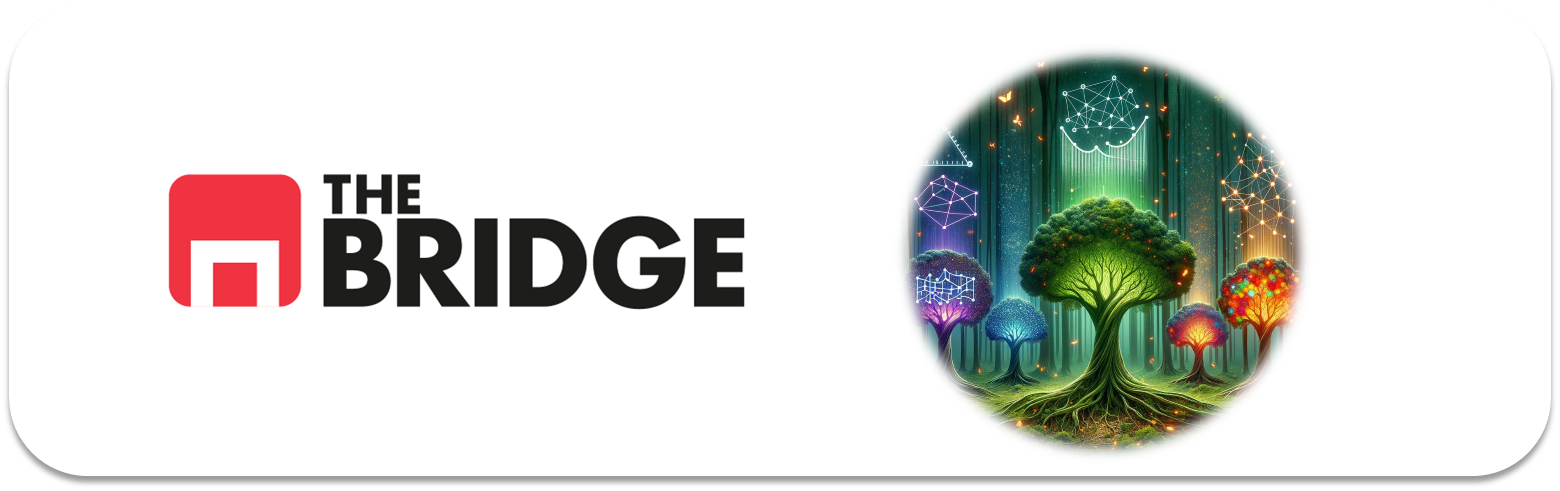

## PRACTICA OBLIGATORIA: **Arboles de Decisión y Ajuste de Hiperparámetros**

* La práctica obligatoria de esta unidad consiste en encontrar el mejor modelo para resolver un problema de predicción de si los destinatarios de una campaña de marketing adquirirán un producto concreto. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [135]:

# Librerías numéricas y de manipulación de datos
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Modelo árbol de decisión y utilidad para visualizarlo
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Modelo de comparación (baseline)
from sklearn.linear_model import LogisticRegression

# Utilidades de partición de datos y búsqueda de hiperparámetros
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score

# Métricas de evaluación para clasificación con clases desbalanceadas
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, f1_score, recall_score)

# Escalado de features (necesario para la regresión logística)
from sklearn.preprocessing import StandardScaler, RobustScaler

# Módulo local de visualización
import bootcampviztools as bcv

import warnings
warnings.filterwarnings('ignore')

# Fijamos semilla global para reproducibilidad
np.random.seed(42)
%matplotlib inline


### Descripción

En el directorio data encontrarás un dataset que contiene datos relacionados con campañas de marketing directo de una institución bancaria portuguesa (es el dataset "Bank Marketing" de la UCI Machine Learning Repository). Los datos se recopilaron de campañas de marketing telefónico, donde el objetivo principal era predecir si el cliente se suscribiría a un depósito a plazo.

La práctica consiste en completar el proceso de creación de un modelo basado en árboles de decisión que permita predecir si un cliente (dadas unas características similares a las del dataset) "comprará" el depósito a plazo. Sigue los pasos necesarios de un proceso de ML para crear el modelo, optimizar sus hiperparámetros, comparar los resultados de esa optimización con una regresión logística (sin optimizar, con sus hiperparámetros por defecto) y finalmente evaluarlo contra test y hacer una pequeña valoración del resultado obtenido.

Tendrás que hacer la limpieza, split, minieda, selección, tratamiento, primeros entrenamientos, optimización, comparación y evaluación según tu mejor criterio. Eso sí, es obligatorio:
- Identificar el target y analizar su distribución
- Realizar una optimización de hiperparámetros, escogiendo un grid medianemante razonado
- Comparar con el modelo baseline
- Evaluar contra test

AYUDA: La dirección del banco nos proporciona estas notas (en inglés):

 
   **bank client data:**  
   1 - age (numeric)  
   2 - job : type of job (categorical: "admin.","unknown","unemployed","management","housemaid","entrepreneur","student",
                                       "blue-collar","self-employed","retired","technician","services")   
   3 - marital : marital status (categorical: "married","divorced","single"; note: "divorced" means divorced or widowed)  
   4 - education (categorical: "unknown","secondary","primary","tertiary")  
   5 - default: has credit in default? (binary: "yes","no")  
   6 - balance: average yearly balance, in euros (numeric)   
   7 - housing: has housing loan? (binary: "yes","no")  
   8 - loan: has personal loan? (binary: "yes","no")   

   **related with the last contact of the current campaign:**  
   9 - contact: contact communication type (categorical: "unknown","telephone","cellular")   
  10 - day: last contact day of the month (numeric)  
  11 - month: last contact month of year (categorical: "jan", "feb", "mar", ..., "nov", "dec")  
  12 - duration: last contact duration, in seconds (numeric)    

   **other attributes:**  
  13 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)  
  14 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric, -1 means client was not previously contacted)  
  15 - previous: number of contacts performed before this campaign and for this client (numeric)  
  16 - poutcome: outcome of the previous marketing campaign (categorical: "unknown","other","failure","success")

  

---
## 1. Carga y primera exploración del dataset

In [136]:
# Cargamos el CSV; el separador es ';' (formato estándar del dataset UCI Bank Marketing)
df = pd.read_csv('data/bank-full.csv', sep=';')

# Verificamos dimensiones: filas x columnas
print(f"Shape: {df.shape}")

# Mostramos las primeras filas para revisar la estructura y los tipos de datos
df.head()


Shape: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [137]:
# Mostramos tipos de dato de cada columna y si hay valores nulos
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 5.9 MB


In [138]:
# Estadísticos básicos de las variables numéricas (media, std, percentiles, min/max)
df.describe()


,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


---
## 2. Identificación del target y análisis de su distribución

El target es la columna `y`: indica si el cliente suscribió (`yes`) o no (`no`) el depósito a plazo.

Distribución del target 'y':
y
no     39922
yes     5289
Name: count, dtype: int64

Porcentaje de 'yes': 11.7%
Porcentaje de 'no':  88.3%


[Text(0, 0, 'No'), Text(1, 0, 'Sí')]

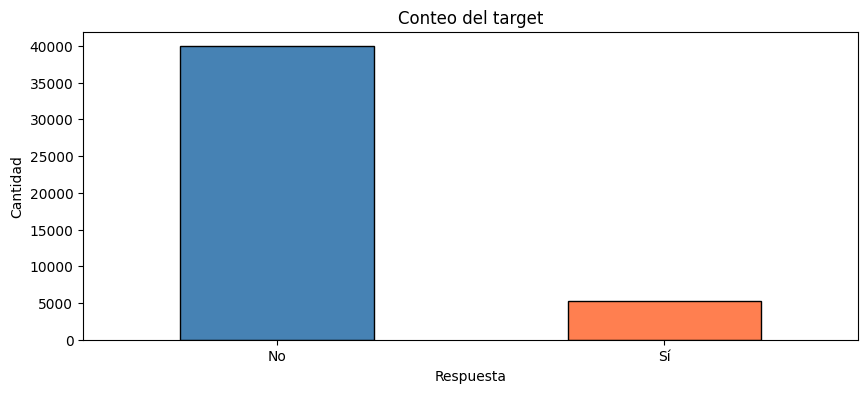

In [139]:
# Contamos cuántos clientes suscribieron (yes) y cuántos no (no)
print("Distribución del target 'y':")
print(df['y'].value_counts())
print(f"\nPorcentaje de 'yes': {df['y'].value_counts(normalize=True)['yes']*100:.1f}%")
print(f"Porcentaje de 'no':  {df['y'].value_counts(normalize=True)['no']*100:.1f}%")

fig, axes = plt.subplots(figsize=(10, 4))

# Gráfico de barras con el conteo absoluto de cada clase
df['y'].value_counts().plot(kind='bar', ax=axes, color=['steelblue', 'coral'], edgecolor='black')
axes.set_title('Conteo del target')
axes.set_xlabel('Respuesta')
axes.set_ylabel('Cantidad')
axes.set_xticklabels(['No', 'Sí'], rotation=0)

**Observación:** El dataset está claramente desbalanceado (~88% No / ~12% Sí). Esto es importante tenerlo en cuenta a la hora de elegir la métrica de evaluación: el **accuracy** puede ser engañoso; usaremos **ROC-AUC** y **F1** como métricas principales.

---
## 3. Limpieza del dataset

In [140]:
# Comprobamos si hay valores nulos reales en el dataframe
print("Valores nulos por columna:")
print(df.isnull().sum())

# Comprobamos si existen filas duplicadas exactas
print(f"\nDuplicados: {df.duplicated().sum()}")


Valores nulos por columna:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

Duplicados: 0


In [141]:
# Seleccionamos solo las columnas de tipo objeto (categóricas)
cat_cols = df.select_dtypes(include='object').columns

# Contamos cuántas veces aparece 'unknown' en cada variable categórica
# 'unknown' no es un nulo real sino una categoría que indica información no disponible
print("Valores 'unknown' por columna categórica:")
for col in cat_cols:
    n = (df[col] == 'unknown').sum()
    if n > 0:
        print(f"  {col}: {n} ({n/len(df)*100:.1f}%)")


Valores 'unknown' por columna categórica:
  job: 288 (0.6%)
  education: 1857 (4.1%)
  contact: 13020 (28.8%)
  poutcome: 36959 (81.7%)


No hay nulos reales. Los valores `unknown` representan una categoría legítima (información no disponible) y los mantenemos como tal: serán una categoría más en el encoding.

---
## 4. Split Train / Test

In [142]:
# Separamos features (X) del target (y)
X = df.drop(columns='y')
y = df['y']

# Dividimos en train (80%) y test (20%)
# stratify=y garantiza que la proporción de clases sea igual en ambos conjuntos
# (importante con clases desbalanceadas)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} filas  |  Test: {X_test.shape[0]} filas")
print(f"Distribución en train — 0: {(y_train==0).mean()*100:.1f}%  |  1: {(y_train==1).mean()*100:.1f}%")
print(f"Distribución en test  — 0: {(y_test==0).mean()*100:.1f}%  |  1: {(y_test==1).mean()*100:.1f}%")


Train: 36168 filas  |  Test: 9043 filas
Distribución en train — 0: 0.0%  |  1: 0.0%
Distribución en test  — 0: 0.0%  |  1: 0.0%


---
## 5. Mini EDA (sobre train)

Analizamos la relación entre las variables numéricas más relevantes y el target, trabajando únicamente sobre el conjunto de train para evitar data leakage.

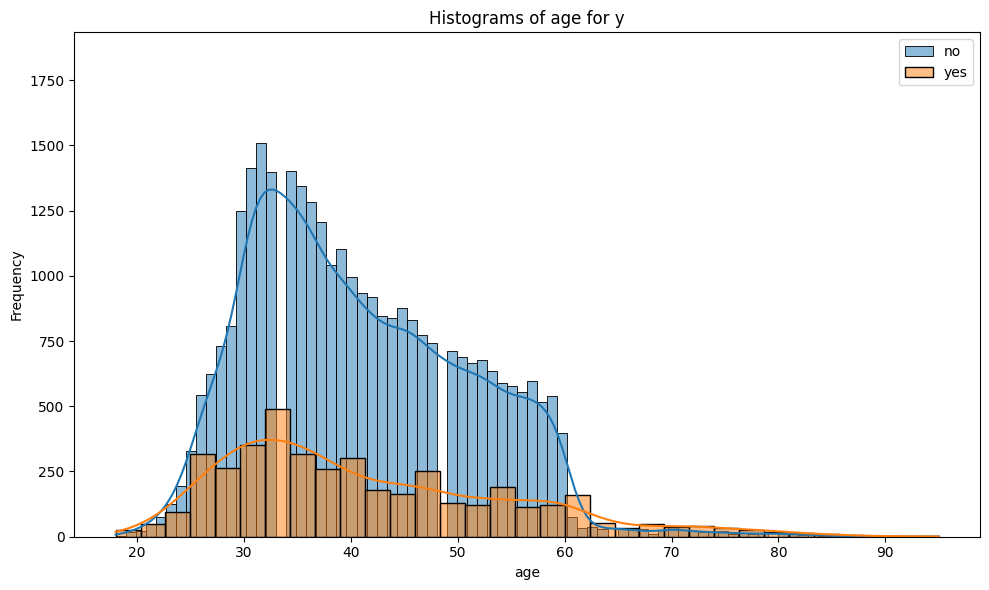

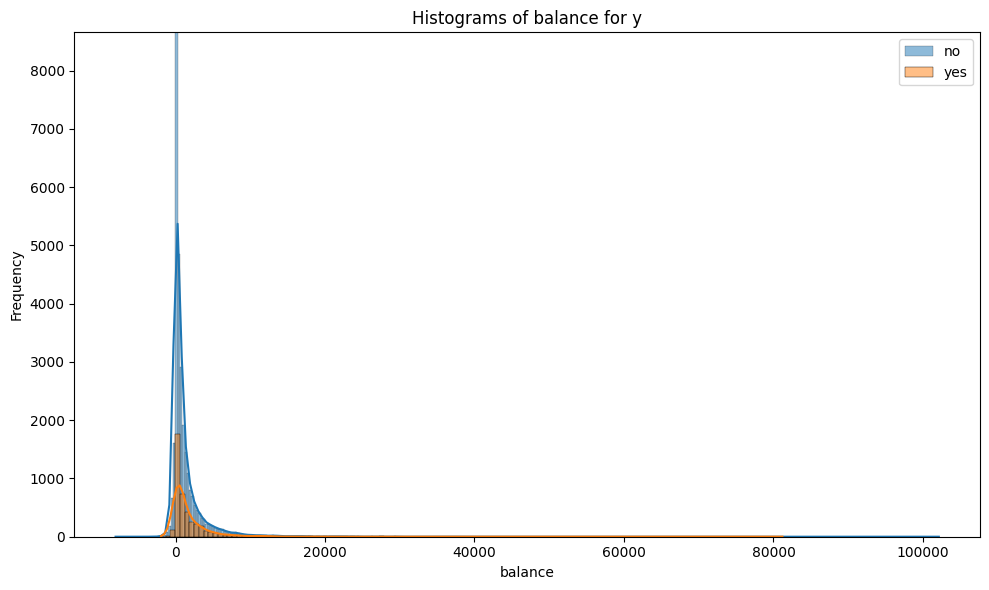

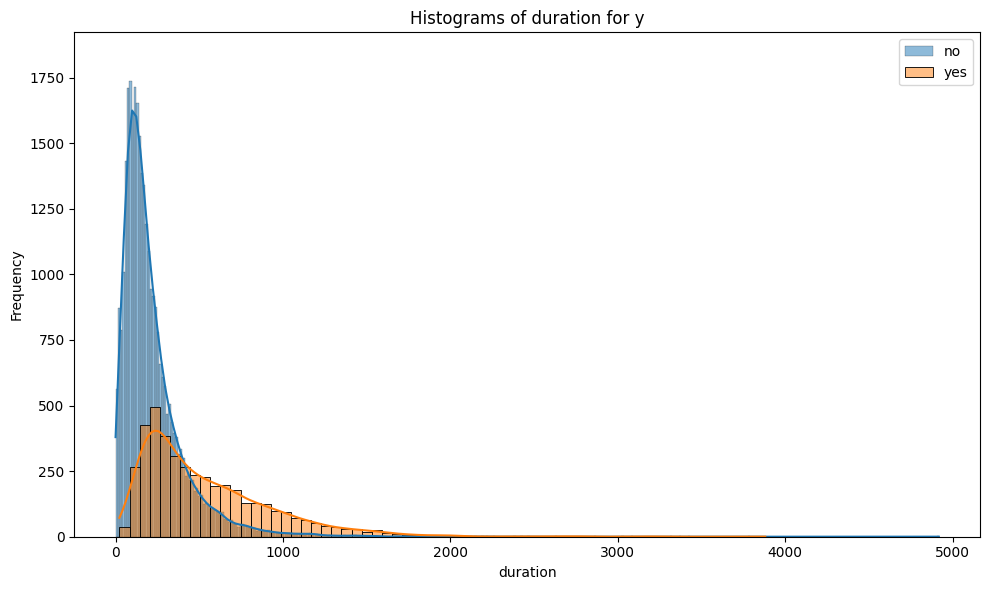

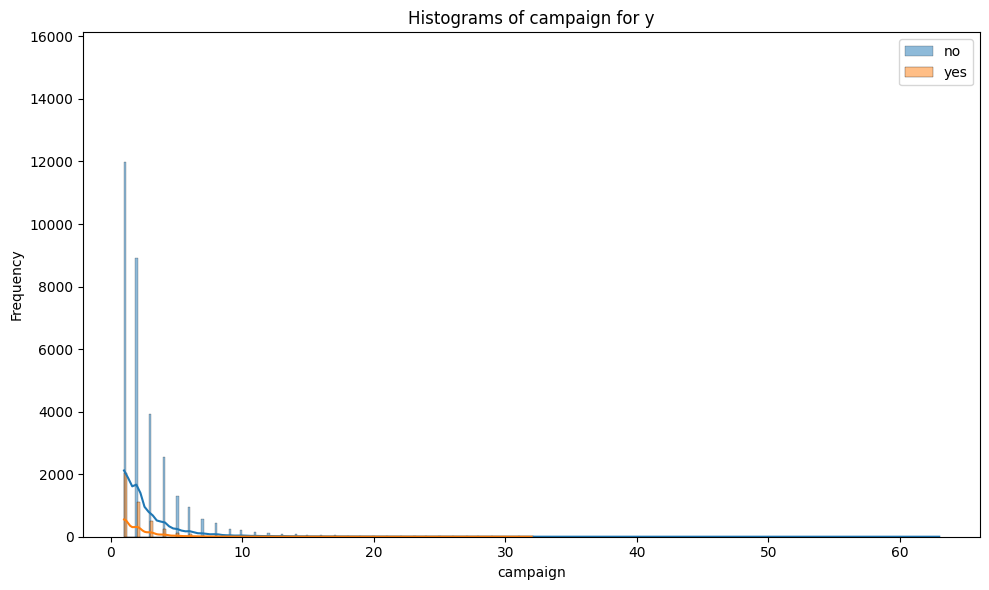

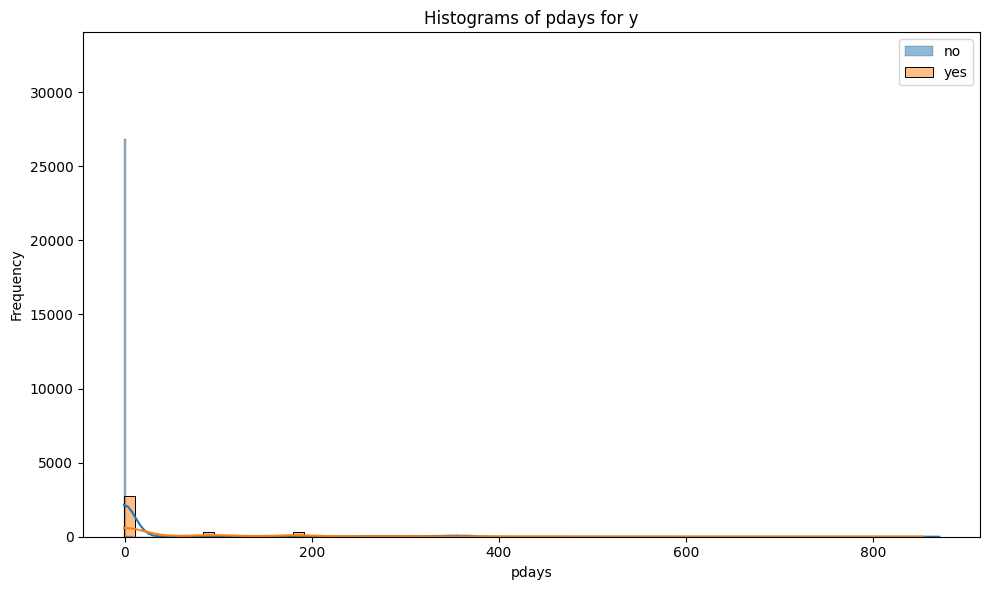

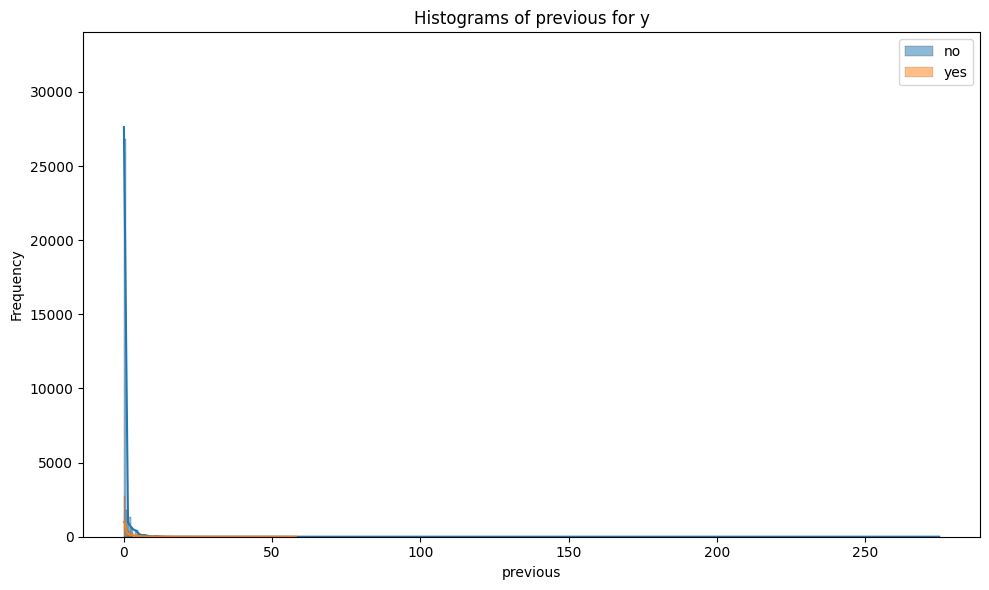

In [143]:
# Extraemos las variables numéricas más relevantes para el análisis exploratorio
num_features = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']

# Unimos features + target para poder agrupar por clase en los boxplots
# Usamos solo el conjunto de train para no contaminar con datos de test (data leakage)
train_eda = X_train[num_features].copy()
train_eda['y'] = y_train.values

for col in num_features:
    bcv.plot_grouped_histograms(
        train_eda,
        cat_col='y',
        num_col=col
    )


### Análisis de variables categóricas (train)

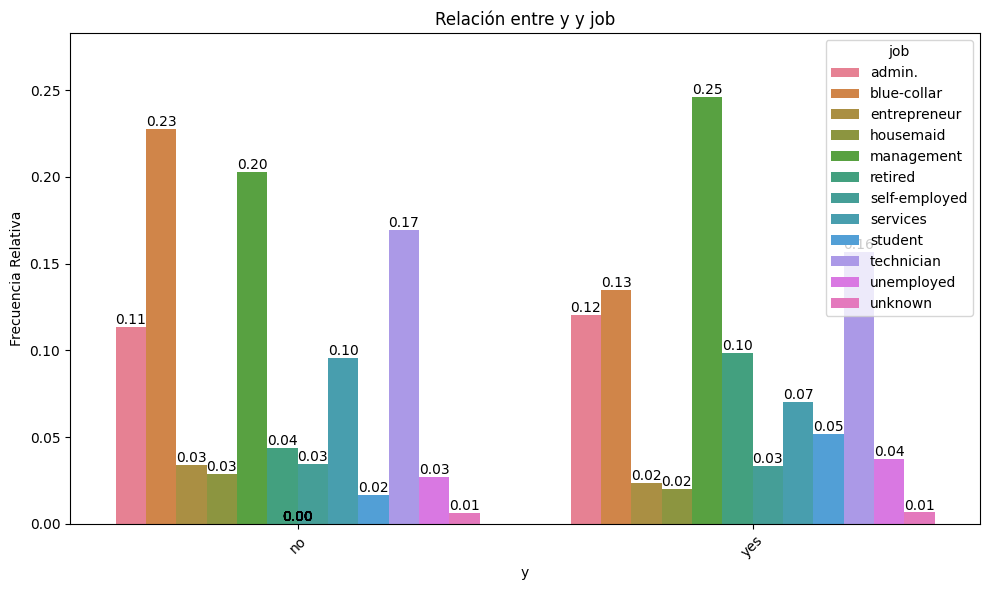

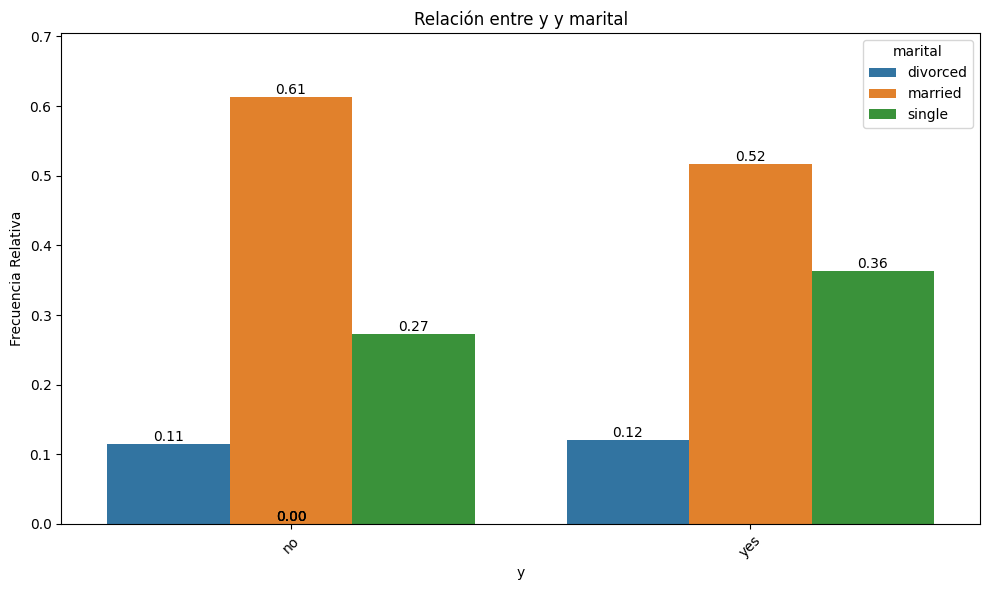

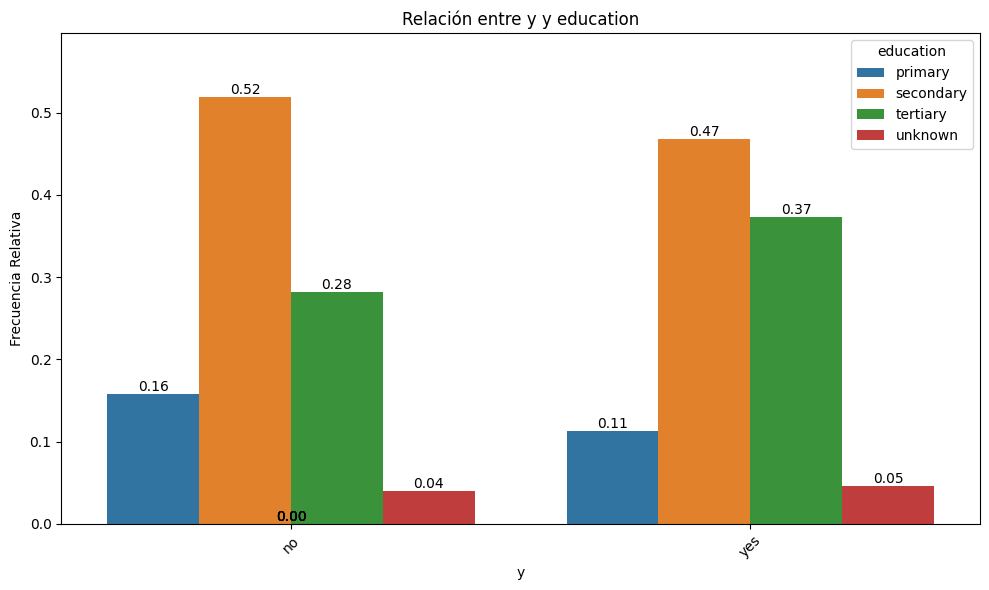

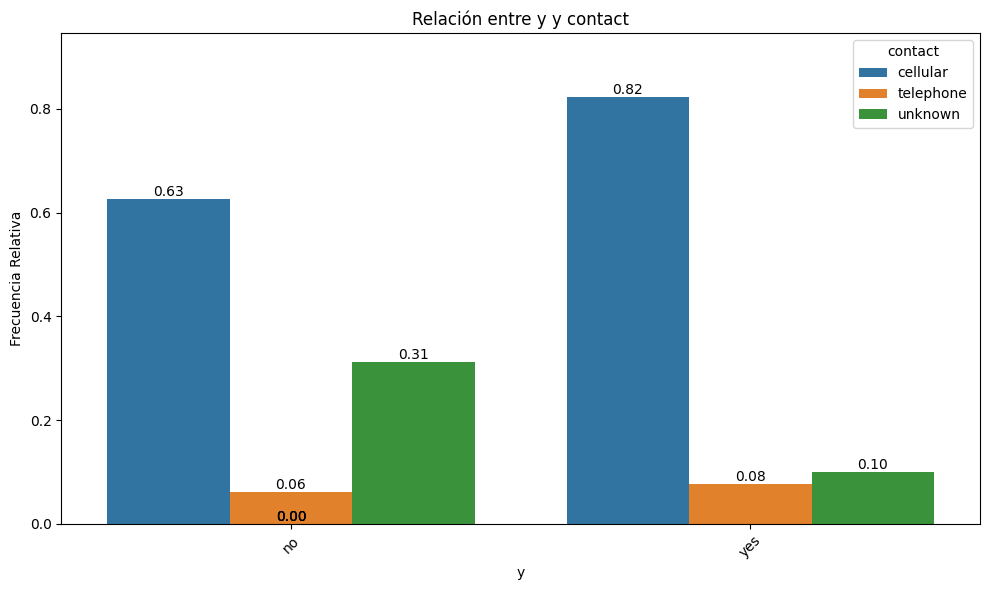

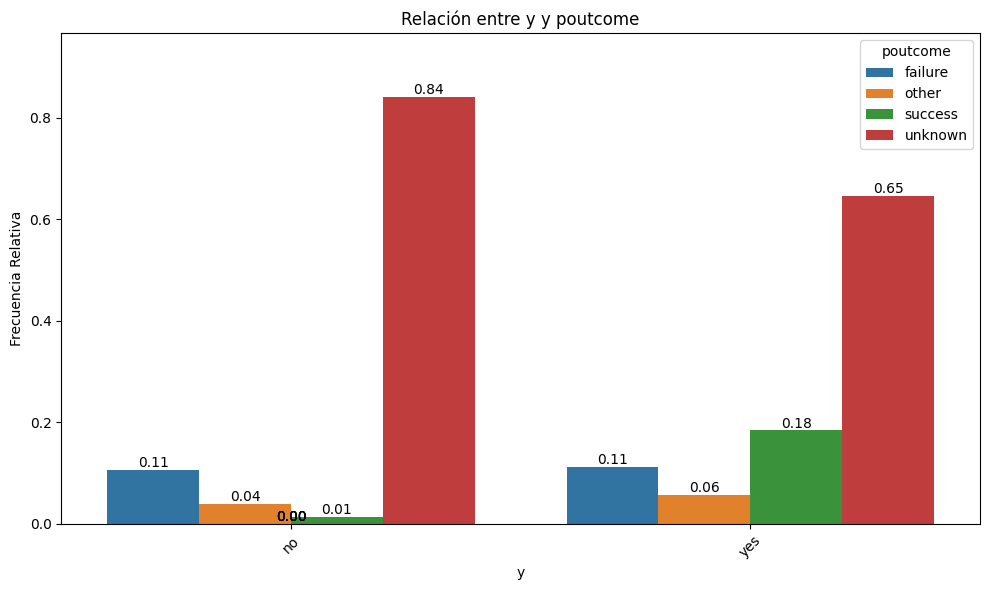

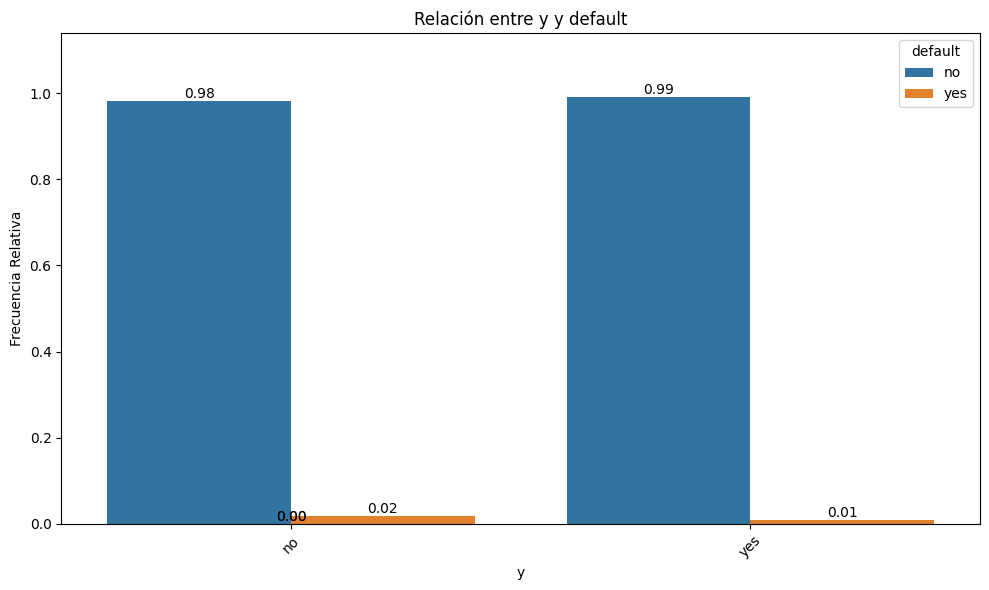

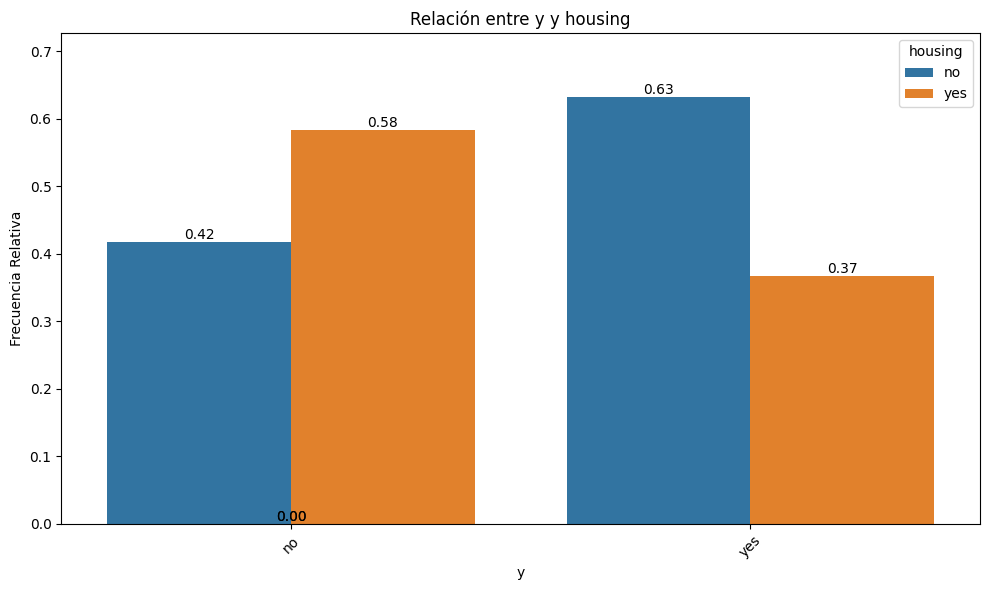

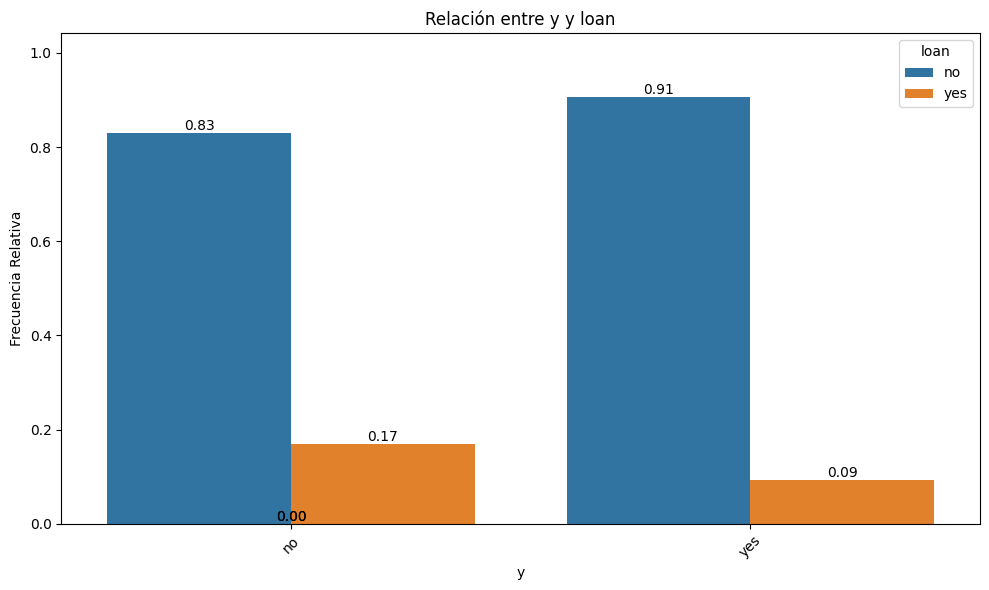

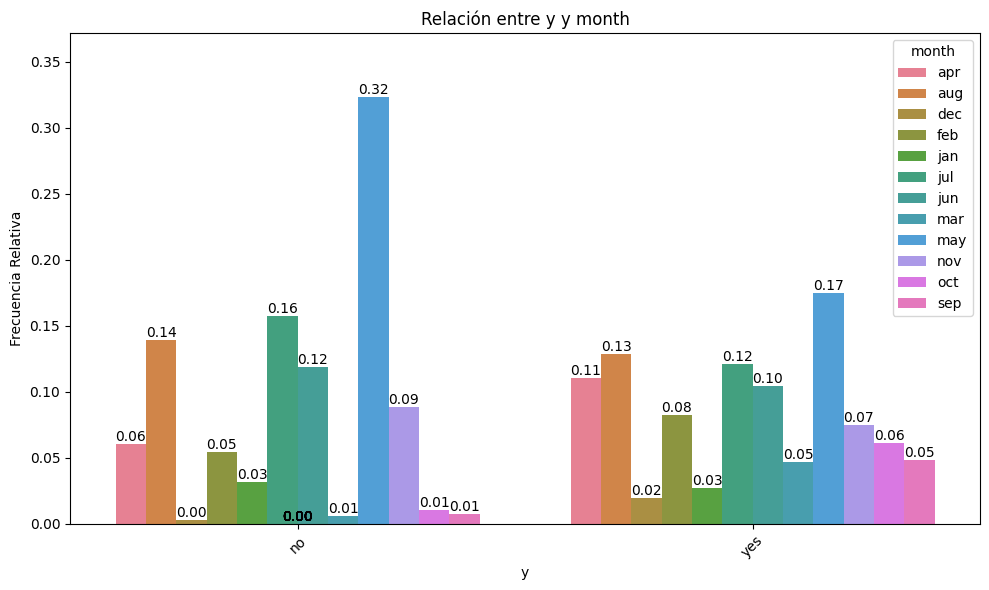

In [144]:
# Recuperamos las filas del train en el dataframe original (antes del encoding)
# para poder visualizar los valores categóricos reales (strings), no los dummies
df_train_orig = df.loc[X_train.index].copy()

# Variables categóricas del dataset original (excluimos el target 'y')
cat_cols_orig = ['job', 'marital', 'education', 'contact', 'poutcome',
                 'default', 'housing', 'loan', 'month']

# pinta_distribucion_categoricas dibuja un gráfico de barras por cada variable
# relativa=True → frecuencias relativas, útil para comparar columnas con muchas categorías
# mostrar_valores=True → anota el porcentaje encima de cada barra
for col in cat_cols_orig:
    bcv.plot_categorical_relationship(
        df_train_orig,
        cat_col1="y",
        cat_col2=col,
        relative_freq=True,
        show_values=True
    )


In [145]:
# Eliminamos default
X_train = X_train.drop(columns='default')
X_test = X_test.drop(columns='default')


---
### Preparación de features (encoding)

In [ ]:
# Si en una ejecución previa se añadió por error el índice 'y', lo eliminamos
if 'y' in y_train.index:
    y_train = y_train.drop(index='y')
if 'y' in y_test.index:
    y_test = y_test.drop(index='y')

# Conversión correcta del target a binario
y_train = y_train.map({'yes': 1, 'no': 0}).astype(int)
y_test = y_test.map({'yes': 1, 'no': 0}).astype(int)

print(y_train.head())
print(y_test.head())
print(len(X_train), len(y_train), len(X_test), len(y_test))

24001     no
43409    yes
20669    yes
18810     no
23130     no
Name: y, dtype: object

In [133]:
# Variables binarias yes/no: las convertimos a 1/0 directamente
for col in ['housing', 'loan']:
    X_train[col] = X_train[col].map({'yes': 1, 'no': 0})
    X_test[col] = X_test[col].map({'yes': 1, 'no': 0})
# Mes del año: lo convertimos a entero ordinal (1 = enero … 12 = diciembre)
# Esto preserva el orden temporal de los meses
month_map = {'jan':1,'feb':2,'mar':3,'apr':4,'may':5,'jun':6,
             'jul':7,'aug':8,'sep':9,'oct':10,'nov':11,'dec':12}
X_train['month'] = X_train['month'].map(month_map)
X_test['month'] = X_test['month'].map(month_map)
# Variables categóricas con más de dos categorías: aplicamos one-hot encoding
# drop_first=True evita multicolinealidad (dummy variable trap)
X_train = pd.get_dummies(X_train, columns=['job','marital','education','contact','poutcome'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['job','marital','education','contact','poutcome'], drop_first=True)

print("Shape tras encoding:", X_train.shape)
print("Columnas:", X_train.columns.tolist())
X_train.head()

Shape tras encoding: (36168, 31)
Columnas: ['age', 'balance', 'housing', 'loan', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired', 'job_self-employed', 'job_services', 'job_student', 'job_technician', 'job_unemployed', 'job_unknown', 'marital_married', 'marital_single', 'education_secondary', 'education_tertiary', 'education_unknown', 'contact_telephone', 'contact_unknown', 'poutcome_other', 'poutcome_success', 'poutcome_unknown']


,age,balance,housing,loan,day,month,duration,campaign,pdays,previous,...,marital_married,marital_single,education_secondary,education_tertiary,education_unknown,contact_telephone,contact_unknown,poutcome_other,poutcome_success,poutcome_unknown
24001,36,861,0,0,29,8,140,2,-1,0,...,False,False,True,False,False,True,False,False,False,True
43409,24,4126,0,0,5,4,907,4,185,7,...,False,True,True,False,False,False,False,False,False,False
20669,44,244,1,0,12,8,1735,4,-1,0,...,False,True,True,False,False,False,False,False,False,True
18810,48,0,0,0,31,7,35,11,-1,0,...,True,False,True,False,False,True,False,False,False,True
23130,38,257,0,0,26,8,57,10,-1,0,...,True,False,True,False,False,False,False,False,False,True


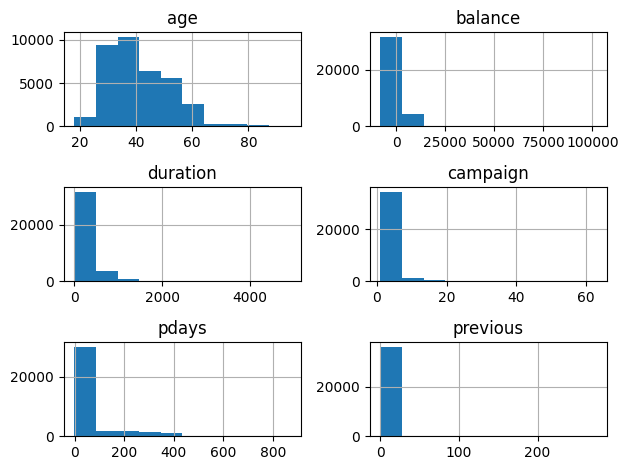

In [114]:
### Numéricas
X_train[num_features].hist()
plt.tight_layout()

In [115]:
X_train["contacted_before"] = X_train['pdays'].apply(lambda x: 1 if x != -1 else 0)
X_test["contacted_before"] = X_test['pdays'].apply(lambda x: 1 if x != -1 else 0)


### Transformaciones y escalado

In [116]:
train_scaled = X_train.copy()
test_scaled = X_test.copy()
train_scaled["balance"] = np.cbrt(train_scaled["balance"])
test_scaled["balance"] = np.cbrt(test_scaled["balance"])

for var,scaler in zip([ "duration", "campaign", "pdays", "previous"], [1,0,2,1]):
    train_scaled[var] = np.log(train_scaled[var] + scaler)
    test_scaled[var] = np.log(test_scaled[var] + scaler)


,age,balance,housing,loan,day,month,duration,campaign,pdays,previous,...,marital_single,education_secondary,education_tertiary,education_unknown,contact_telephone,contact_unknown,poutcome_other,poutcome_success,poutcome_unknown,contacted_before
24001,36,9.513370,0,0,29,8,4.948760,0.693147,0.000000,0.000000,...,False,True,False,False,True,False,False,False,True,0
43409,24,16.038968,0,0,5,4,6.811244,1.386294,5.231109,2.079442,...,True,True,False,False,False,False,False,False,False,1
20669,44,6.248800,1,0,12,8,7.459339,1.386294,0.000000,0.000000,...,True,True,False,False,False,False,False,False,True,0
18810,48,0.000000,0,0,31,7,3.583519,2.397895,0.000000,0.000000,...,False,True,False,False,True,False,False,False,True,0
23130,38,6.357861,0,0,26,8,4.060443,2.302585,0.000000,0.000000,...,False,True,False,False,False,False,False,False,True,0


In [117]:
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(train_scaled)   # aprende media/std del train y transforma
X_test_scaled  = scaler.transform(test_scaled)         # aplica la misma transformación al test

In [120]:
y_train

24001                                                   no
43409                                                  yes
20669                                                  yes
18810                                                   no
23130                                                   no
                               ...                        
15941                                                   no
16952                                                   no
34781                                                   no
44229                                                  yes
y        24001    0
43409    1
20669    1
18810    0
23...
Name: y, Length: 36169, dtype: object

In [119]:
# Árbol sin ninguna restricción: crecerá hasta que todas las hojas sean puras
# Esto suele producir overfitting (memoriza el train pero generaliza mal)
tree_base = DecisionTreeClassifier(random_state=42)
tree_base.fit(X_train_scaled, y_train)

# Evaluamos con validación cruzada de 5 folds sobre train
# F1: equilibrio entre precision y recall de la clase positiva (suscribió=1)
cv_f1_base = cross_val_score(tree_base, X_train_scaled, y_train, cv=5, scoring='f1')
# Recall: proporción de clientes que realmente suscriben y el modelo detecta correctamente
cv_recall_base = cross_val_score(tree_base, X_train_scaled, y_train, cv=5, scoring='recall')

print(f"Árbol base (sin optimizar)")
print(f"  F1     CV (train): {cv_f1_base.mean():.4f} ± {cv_f1_base.std():.4f}")
print(f"  Recall CV (train): {cv_recall_base.mean():.4f} ± {cv_recall_base.std():.4f}")

# Una profundidad muy alta confirma que el árbol se ha sobreajustado
print(f"  Profundidad del árbol: {tree_base.get_depth()}")
print(f"  Nº de hojas: {tree_base.get_n_leaves()}")


ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

El árbol sin restricciones crece hasta memorizar el train (overfitting). La profundidad suele ser muy alta con un ROC-AUC en CV inferior al óptimo. Necesitamos optimizar los hiperparámetros.

---
## 8. Optimización de hiperparámetros con GridSearchCV

In [ ]:
# Definimos el espacio de búsqueda de hiperparámetros:
# - max_depth: profundidad máxima del árbol; limita el overfitting
#     · None = sin límite (árbol completo); valores pequeños = árbol más simple/generalizable
# - min_samples_split: nº mínimo de muestras para que un nodo pueda dividirse
#     · valores altos → menos divisiones → árbol más conservador
# - min_samples_leaf: nº mínimo de muestras que debe tener cada hoja
#     · actúa como regularización suavizando regiones con pocos datos
# - class_weight: penalización por clase, clave en datasets desbalanceados
#     · None      → todas las muestras tienen el mismo peso (ignora el desbalanceo)
#     · 'balanced'→ ajusta los pesos inversamente proporcional a la frecuencia de cada clase
#                   (la clase minoritaria "Sí" recibe ~7-8x más peso que "No")
#     · {0:1,1:3} → peso manual: penaliza 3 veces más los errores en la clase positiva
param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 10, 20],
    'min_samples_leaf': [1, 5, 10],
    'class_weight': [None, 'balanced', {0: 1, 1: 3}, {0: 1, 1: 5}]
}

# GridSearchCV con dos métricas simultáneas: F1 y Recall de la clase positiva
# refit='f1' indica que el mejor modelo se selecciona y re-entrena según F1
# (Recall también se calcula y queda accesible en cv_results_)
grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring={'f1': 'f1', 'recall': 'recall'},
    refit='f1',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

# Recuperamos las métricas del mejor modelo según F1
best_idx = grid_search.best_index_
best_f1_cv     = grid_search.cv_results_['mean_test_f1'][best_idx]
best_recall_cv = grid_search.cv_results_['mean_test_recall'][best_idx]

print("\nMejores hiperparámetros encontrados:")
print(grid_search.best_params_)
print(f"\nMejor F1     en CV (train): {best_f1_cv:.4f}")
print(f"Recall       en CV (train): {best_recall_cv:.4f}")


Fitting 5 folds for each of 180 candidates, totalling 900 fits


KeyboardInterrupt: 

Árbol optimizado — profundidad: 10  |  hojas: 349


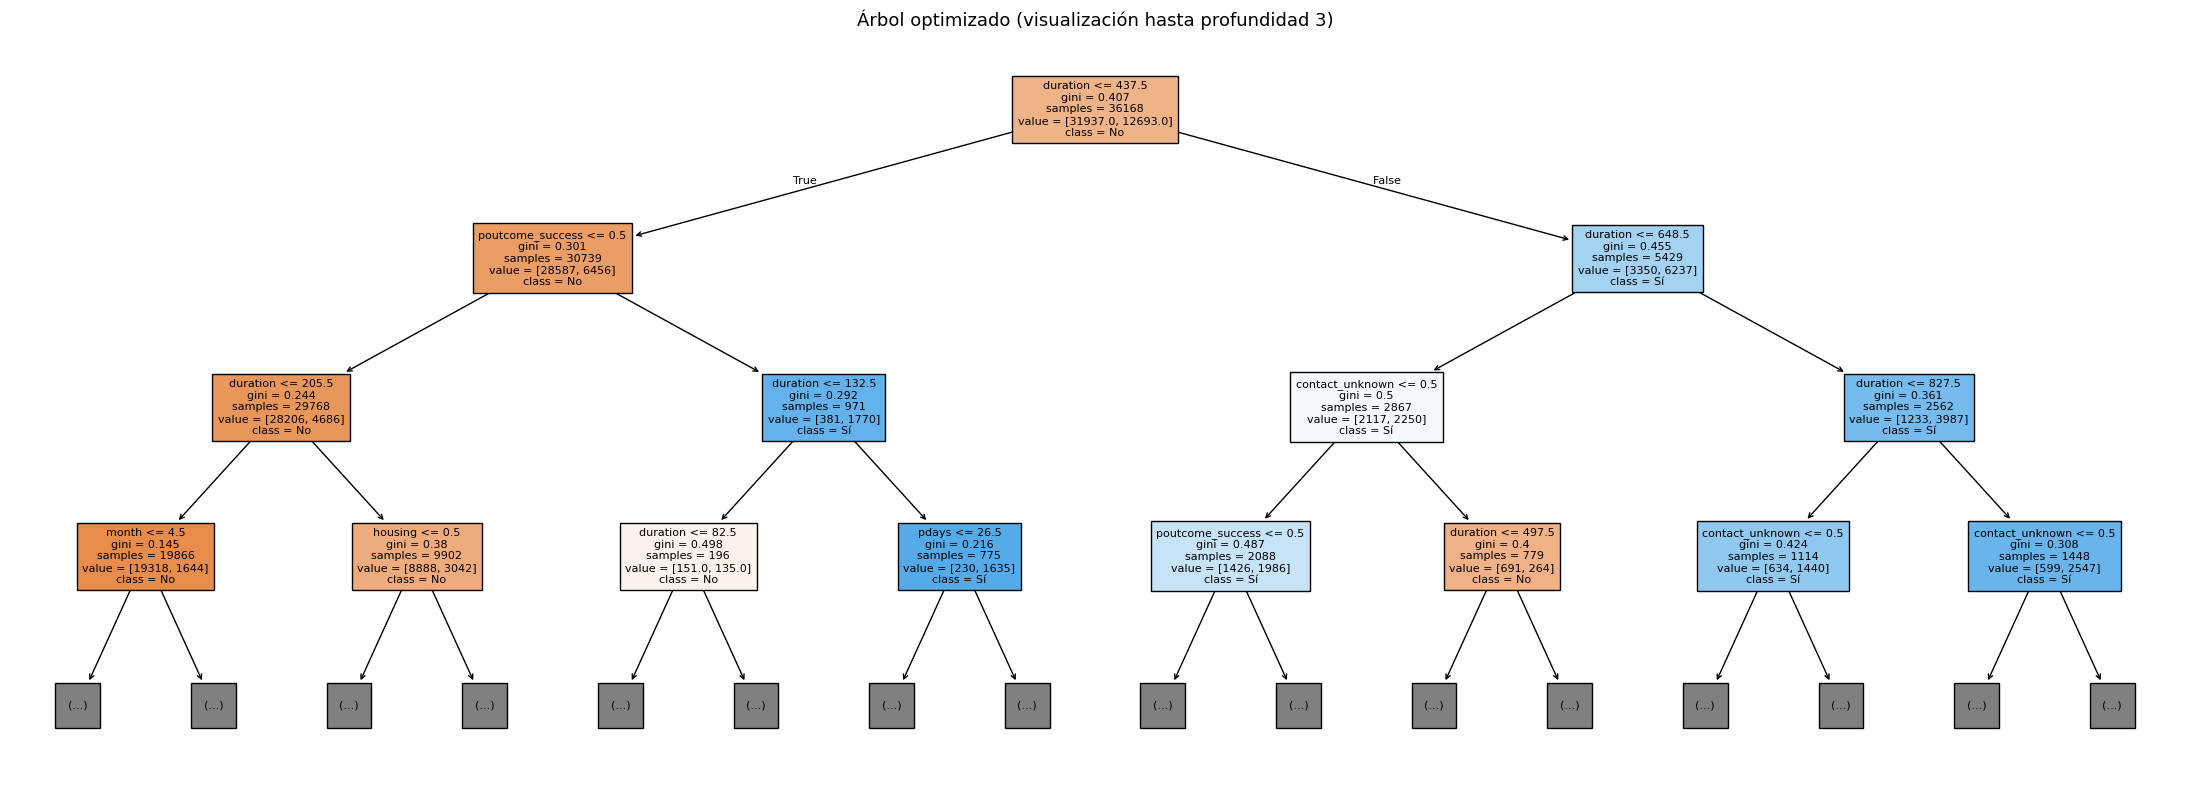

In [ ]:
# Recuperamos el mejor estimador encontrado por GridSearchCV
best_tree = grid_search.best_estimator_

print(f"Árbol optimizado — profundidad: {best_tree.get_depth()}  |  hojas: {best_tree.get_n_leaves()}")

# Visualizamos la estructura del árbol limitando a profundidad 3 para que sea legible
# filled=True colorea los nodos según la clase mayoritaria
# feature_names y class_names añaden etiquetas comprensibles en los nodos
plt.figure(figsize=(22, 8))
plot_tree(best_tree, feature_names=X_train.columns.tolist(),
          class_names=['No', 'Sí'], filled=True, max_depth=3, fontsize=8)
plt.title("Árbol optimizado (visualización hasta profundidad 3)", fontsize=13)
plt.tight_layout()
plt.show()


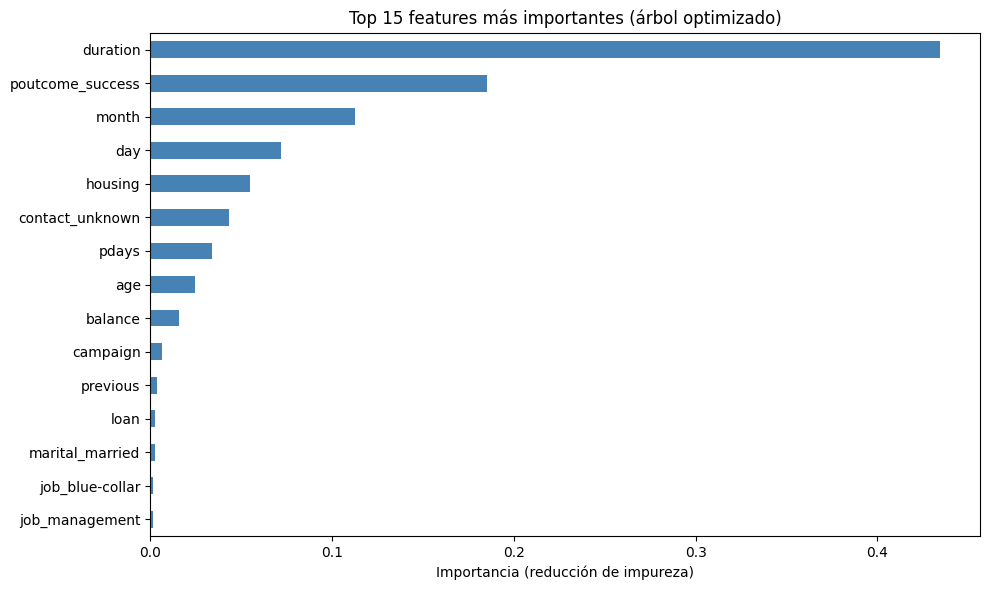

In [ ]:
# Feature importances: mide cuánto reduce cada feature la impureza (Gini/Entropy) en promedio
# Los valores suman 1; cuanto mayor, más relevante es la variable para las decisiones del árbol
importances = pd.Series(best_tree.feature_importances_, index=X_train.columns)
top15 = importances.sort_values(ascending=True).tail(15)

plt.figure(figsize=(10, 6))
top15.plot(kind='barh', color='steelblue')
plt.title('Top 15 features más importantes (árbol optimizado)')
plt.xlabel('Importancia (reducción de impureza)')
plt.tight_layout()
plt.show()


---
## 9. Comparación con Regresión Logística (sin optimizar, hiperparámetros por defecto)

La regresión logística necesita escalado de features para funcionar correctamente, a diferencia del árbol de decisión.

In [ ]:
# Regresión logística con hiperparámetros por defecto (sin optimizar)
# max_iter=1000 para garantizar convergencia en este dataset
logreg = LogisticRegression(random_state=42, max_iter=1000)
logreg.fit(X_train_scaled, y_train)

# Evaluación con CV usando F1 y Recall para comparar en igualdad de condiciones con el árbol
cv_f1_logreg     = cross_val_score(logreg, X_train_scaled, y_train, cv=5, scoring='f1')
cv_recall_logreg = cross_val_score(logreg, X_train_scaled, y_train, cv=5, scoring='recall')

print(f"Regresión Logística (default)")
print(f"  F1     CV (train): {cv_f1_logreg.mean():.4f} ± {cv_f1_logreg.std():.4f}")
print(f"  Recall CV (train): {cv_recall_logreg.mean():.4f} ± {cv_recall_logreg.std():.4f}")


Regresión Logística (default)
  F1     CV (train): 0.4349 ± 0.0126
  Recall CV (train): 0.3297 ± 0.0158


In [ ]:
# Construimos una tabla comparativa con F1 y Recall de la clase positiva (Sí=1)
# para los tres modelos, tanto en CV (train) como en test (datos no vistos)
results = {
    'Árbol base (sin optimizar)': {
        'F1 CV':       cv_f1_base.mean(),
        'Recall CV':   cv_recall_base.mean(),
        'F1 test':     f1_score(y_test, tree_base.predict(X_test)),
        'Recall test': recall_score(y_test, tree_base.predict(X_test)),
    },
    'Árbol optimizado (GridSearch)': {
        'F1 CV':       best_f1_cv,
        'Recall CV':   best_recall_cv,
        'F1 test':     f1_score(y_test, best_tree.predict(X_test)),
        'Recall test': recall_score(y_test, best_tree.predict(X_test)),
    },
    'Regresión Logística (default)': {
        'F1 CV':       cv_f1_logreg.mean(),
        'Recall CV':   cv_recall_logreg.mean(),
        'F1 test':     f1_score(y_test, logreg.predict(X_test_scaled)),
        'Recall test': recall_score(y_test, logreg.predict(X_test_scaled)),
    }
}

df_results = pd.DataFrame(results).T.round(4)
print(df_results)


                                F1 CV  Recall CV  F1 test  Recall test
Árbol base (sin optimizar)     0.4759     0.4831   0.4704       0.4773
Árbol optimizado (GridSearch)  0.5748     0.7013   0.5732       0.7051
Regresión Logística (default)  0.4349     0.3297   0.4271       0.3223


---
## 10. Evaluación final en Test

Evaluamos los dos mejores candidatos con detalle sobre el conjunto de test.

In [ ]:
# classification_report muestra precision, recall y F1 por clase
# Nos fijamos especialmente en la clase 1 (suscribió) porque es la que nos interesa predecir
print("=" * 50)
print("ÁRBOL OPTIMIZADO — Reporte en Test")
print("=" * 50)
print(classification_report(y_test, best_tree.predict(X_test), target_names=['No (0)', 'Sí (1)']))

print("=" * 50)
print("REGRESIÓN LOGÍSTICA — Reporte en Test")
print("=" * 50)
print(classification_report(y_test, logreg.predict(X_test_scaled), target_names=['No (0)', 'Sí (1)']))


ÁRBOL OPTIMIZADO — Reporte en Test
              precision    recall  f1-score   support

      No (0)       0.96      0.90      0.93      7985
      Sí (1)       0.48      0.71      0.57      1058

    accuracy                           0.88      9043
   macro avg       0.72      0.80      0.75      9043
weighted avg       0.90      0.88      0.89      9043

REGRESIÓN LOGÍSTICA — Reporte en Test
              precision    recall  f1-score   support

      No (0)       0.92      0.98      0.94      7985
      Sí (1)       0.63      0.32      0.43      1058

    accuracy                           0.90      9043
   macro avg       0.77      0.65      0.69      9043
weighted avg       0.88      0.90      0.88      9043



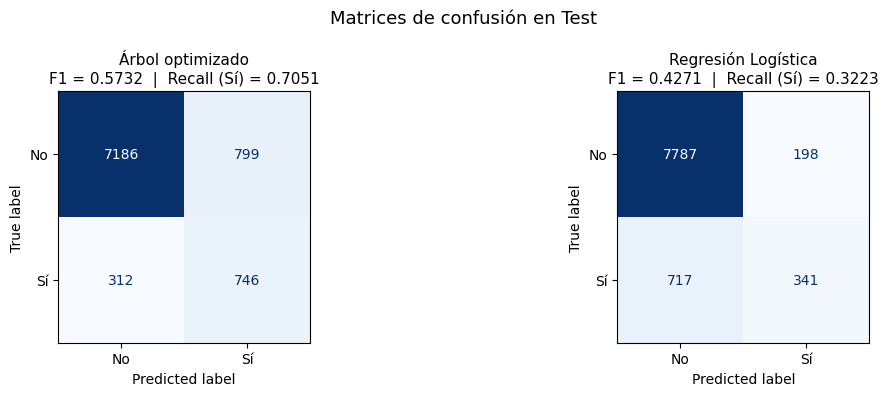

In [ ]:

# Matrices de confusión: muestran los aciertos y errores por clase
# - Verdaderos Negativos (TN): predijo No y era No
# - Falsos Positivos (FP): predijo Sí pero era No  → clientes contactados innecesariamente
# - Falsos Negativos (FN): predijo No pero era Sí  → oportunidades perdidas
# - Verdaderos Positivos (TP): predijo Sí y era Sí
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (nombre, modelo, X_t) in zip(axes, [
    ('Árbol optimizado', best_tree, X_test),
    ('Regresión Logística', logreg, X_test_scaled)
]):
    cm = confusion_matrix(y_test, modelo.predict(X_t))
    disp = ConfusionMatrixDisplay(cm, display_labels=['No', 'Sí'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    # Mostramos F1 y Recall de la clase positiva (Sí=1) en el título de cada gráfico
    f1  = f1_score(y_test, modelo.predict(X_t))
    rec = recall_score(y_test, modelo.predict(X_t))
    ax.set_title(f"{nombre}\nF1 = {f1:.4f}  |  Recall (Sí) = {rec:.4f}", fontsize=11)

plt.suptitle('Matrices de confusión en Test', fontsize=13)
plt.tight_layout()
plt.show()
